In [2]:
# import required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# load the dataset
df = pd.read_csv("decision_tree_dataset.csv")

In [5]:
# check the first 5 rows of the dataset
df.head()

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0


In [6]:
# check missing values
df.isnull().sum()

age               0
income          103
credit_score    104
city              0
gender            0
purchases         0
loan_amount     103
approved          0
dtype: int64

In [7]:
# check the statistical summary of the dataset
df.describe()

,age,income,credit_score,purchases,loan_amount,approved
count,1050.000000,947.000000,946.000000,1050.000000,9.470000e+02,1050.000000
mean,43.737143,55807.648029,651.605495,2.934286,2.086066e+05,0.303810
std,15.021797,40021.647680,100.166162,1.603281,1.270517e+05,0.460121
min,18.000000,6556.169327,348.048784,0.000000,-5.768131e+04,0.000000
25%,31.000000,40886.541936,584.998140,2.000000,1.378232e+05,0.000000
50%,44.000000,50967.116222,650.052796,3.000000,1.971923e+05,0.000000
75%,56.000000,60643.014837,718.563117,4.000000,2.598691e+05,1.000000
max,69.000000,445126.233564,969.310757,9.000000,1.233105e+06,1.000000


In [8]:
#  value counts of the target variable
df["approved"].value_counts()

approved
0    731
1    319
Name: count, dtype: int64

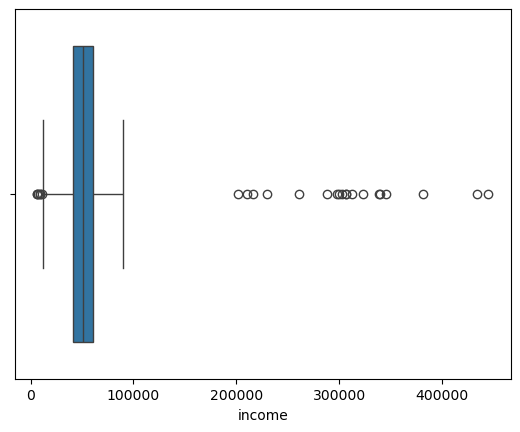

In [9]:
# box plot of the "income" column
sns.boxplot(x=df["income"])
plt.show()

In [10]:
# display the income column of outlier rows using the IQR method
Q1 = df["income"].quantile(0.25)
Q3 = df["income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["income"] < lower_bound) | (df["income"] > upper_bound)]
print(outliers["income"])

35     229759.379853
41       6556.169327
98     345366.632125
100    210785.497964
105      7271.860691
299    340091.044162
314      6556.169327
334     11134.365618
398    445126.233564
413    323701.823796
543    434147.510493
641    381218.255739
670      9546.700356
678    312676.908405
742    307031.099211
746    339129.495509
761    298204.206990
769      9546.700356
822    306919.644234
868    288099.349518
880    303175.281819
895    216587.310895
919    261150.059290
946    201736.132721
954    299716.095150
Name: income, dtype: float64


In [12]:
# check number of outliers in the "income" column
num_outliers = outliers.shape[0]
print("Number of outliers in the 'income' column:", num_outliers)

Number of outliers in the 'income' column: 25


In [13]:
# display the outlier in the loan_amount column using the IQR method
Q1 = df["loan_amount"].quantile(0.25)
Q3 = df["loan_amount"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["loan_amount"] < lower_bound) | (df["loan_amount"] > upper_bound)]
print(outliers["loan_amount"])

33      5.111011e+05
87      9.278302e+05
96      4.823244e+05
100     7.284888e+05
117     5.118565e+05
141     1.073013e+06
186     7.784863e+05
396     6.538568e+05
425     8.784366e+05
432     1.079089e+06
464     1.148652e+06
556     4.494145e+05
561     1.233105e+06
582     6.538568e+05
611    -5.768131e+04
745     7.078701e+05
782     4.823244e+05
809     9.931666e+05
828     8.642236e+05
904     1.219157e+06
987     6.150037e+05
1032    5.997069e+05
Name: loan_amount, dtype: float64


In [15]:
# Check the number of outliers in the "loan_amount" column
num_outliers_loan_amount = outliers.shape[0]
print("Number of outliers in the 'loan_amount' column:", num_outliers_loan_amount)

Number of outliers in the 'loan_amount' column: 22


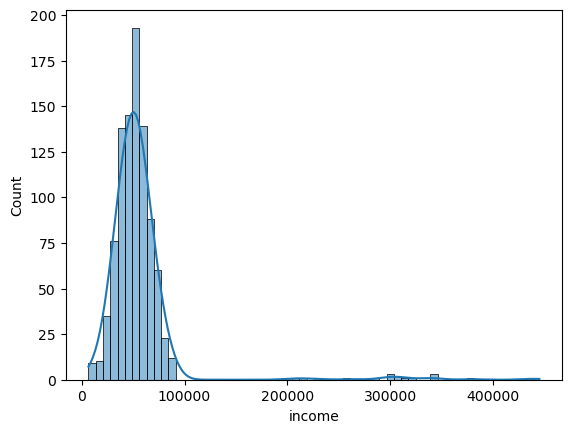

In [16]:
# distribution plot of the "income" column
sns.histplot(df["income"], kde=True)    
plt.show()

In [17]:
# handled  missing value with median value
df["income"].fillna(df["income"].median(), inplace=True)
df["credit_score"].fillna(df["credit_score"].median(), inplace=True)
df["loan_amount"].fillna(df["loan_amount"].median(), inplace=True)


C:\Users\Sumit\AppData\Local\Temp\ipykernel_20788\157963744.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income"].fillna(df["income"].median(), inplace=True)
C:\Users\Sumit\AppData\Local\Temp\ipykernel_20788\157963744.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [18]:
df.isnull().sum()

age             0
income          0
credit_score    0
city            0
gender          0
purchases       0
loan_amount     0
approved        0
dtype: int64

In [19]:
# use clip method to handle outliers in the "income" column
def cap_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

In [20]:
#  use the function to cap outliers in the "income" and "loan_amount" columns
cap_outlier("income")
cap_outlier("loan_amount")


In [21]:
# display load_amount column
print(df["loan_amount"])

0       197192.282657
1       109037.369348
2       140981.063625
3       265765.286243
4       187481.809910
            ...      
1045    124867.554418
1046     19776.528421
1047    195876.623311
1048    115295.988140
1049    197192.282657
Name: loan_amount, Length: 1050, dtype: float64


In [22]:
# chcek the datatype of the columns
print(df.dtypes)

age               int64
income          float64
credit_score    float64
city             object
gender           object
purchases         int64
loan_amount     float64
approved          int64
dtype: object


In [23]:
# use round function to loan_amount column to 2 decimal places
df["loan_amount"] = df["loan_amount"].round(2)

In [24]:
# check the unique value in the city column
print(df["city"].unique())

['Hyderabad' 'Bangalore' 'Mumbai' 'Delhi']


In [25]:
# check the unique value in the gender column
print(df["gender"].unique())

['Female' 'Male']


In [27]:
# handled the categorical variable with one hot encoding using sklearn library
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

# fit and transform the city column
city_encoded = encoder.fit_transform(df[["city"]])


In [28]:
city_encoded

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.]], shape=(1050, 4))

In [32]:
# convert the encoded city column to a dataframe
city_encoded_df = pd.DataFrame(city_encoded, columns=encoder.get_feature_names_out(["city"]))
city_encoded_df.astype(int)

,city_Bangalore,city_Delhi,city_Hyderabad,city_Mumbai
0,0,0,1,0
1,1,0,0,0
2,1,0,0,0
3,0,0,0,1
4,0,1,0,0
...,...,...,...,...
1045,1,0,0,0
1046,0,1,0,0
1047,0,0,0,1
1048,0,0,0,1


In [33]:
# concatenate the original dataframe with the encoded city dataframe
df = pd.concat([df, city_encoded_df], axis=1)

In [34]:
df.head()

,age,income,credit_score,city,gender,purchases,loan_amount,approved,city_Bangalore,city_Delhi,city_Hyderabad,city_Mumbai
0,41,16832.970365,646.435852,Hyderabad,Female,2,197192.28,0,0.0,0.0,1.0,0.0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.37,0,1.0,0.0,0.0,0.0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.06,0,1.0,0.0,0.0,0.0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.29,0,0.0,0.0,0.0,1.0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.81,0,0.0,1.0,0.0,0.0


In [35]:
# drop the city column
df.drop("city", axis=1, inplace=True)

In [36]:
# convert all the city encoded columns to integer type
for col in city_encoded_df.columns:
    df[col] = df[col].astype(int)

In [37]:
df.head()

,age,income,credit_score,gender,purchases,loan_amount,approved,city_Bangalore,city_Delhi,city_Hyderabad,city_Mumbai
0,41,16832.970365,646.435852,Female,2,197192.28,0,0,0,1,0
1,61,24958.920783,772.103370,Female,2,109037.37,0,1,0,0,0
2,29,26661.565307,742.165011,Male,3,140981.06,0,1,0,0,0
3,40,76918.367953,789.568381,Female,2,265765.29,0,0,0,0,1
4,18,33446.160242,650.679984,Male,4,187481.81,0,0,1,0,0


In [38]:
# gender column value replacement with 0 and 1
df["gender"] = df["gender"].replace({"Male": 0, "Female": 1})

C:\Users\Sumit\AppData\Local\Temp\ipykernel_20788\2329394692.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"] = df["gender"].replace({"Male": 0, "Female": 1})


In [39]:
# credit_score convert to integer type
df["credit_score"] = df["credit_score"].astype(int)

In [40]:
df.head()

,age,income,credit_score,gender,purchases,loan_amount,approved,city_Bangalore,city_Delhi,city_Hyderabad,city_Mumbai
0,41,16832.970365,646,1,2,197192.28,0,0,0,1,0
1,61,24958.920783,772,1,2,109037.37,0,1,0,0,0
2,29,26661.565307,742,0,3,140981.06,0,1,0,0,0
3,40,76918.367953,789,1,2,265765.29,0,0,0,0,1
4,18,33446.160242,650,0,4,187481.81,0,0,1,0,0


In [41]:
# divide the dataset into features and target variable
X = df.drop("approved",axis=1)
y = df["approved"]

In [42]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# train decision tree classifier
from sklearn.tree import DecisionTreeClassifier

# Load the model
model = DecisionTreeClassifier()

# fit the model on the training data
model.fit(X_train, y_train)

# predict the target variable on the testing set
y_pred = model.predict(X_test)

In [46]:
# make dataframe of actual and predicted values
results_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results_df.head()

,Actual,Predicted
352,0,0
689,1,1
485,1,1
388,1,1
31,1,0


In [48]:
# check the metric of the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       152
           1       0.91      0.90      0.90        58

    accuracy                           0.95       210
   macro avg       0.94      0.93      0.93       210
weighted avg       0.95      0.95      0.95       210



In [49]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[147   5]
 [  6  52]]


In [50]:
print("Accuracy Score:\n", accuracy_score(y_test, y_pred))

Accuracy Score:
 0.9476190476190476


In [51]:
# training accuracy
y_train_pred = model.predict(X_train)
print("Training Accuracy Score:\n", accuracy_score(y_train, y_train_pred))

Training Accuracy Score:
 1.0


## Pre Pruning 

In [52]:
from sklearn.tree import DecisionTreeClassifier

# LOAD THE MODEL
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split= 4,
    min_samples_leaf=4
)

# fit the model on the training data
model.fit(X_train, y_train)

# predict the target variable on the testing set
y_pred = model.predict(X_test)




In [53]:
# check accuracy score of the model train and test data
print("Testing Accuracy Score:\n", accuracy_score(y_test, y_pred))
print("Training Accuracy Score:\n", accuracy_score(y_train, model.predict(X_train)))


Testing Accuracy Score:
 0.9761904761904762
Training Accuracy Score:
 0.9714285714285714
